In [1]:
from pathlib import Path
import getpass
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sqlalchemy import create_engine, text
from sqlalchemy.exc import SQLAlchemyError

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    roc_curve
)

import joblib

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 200)

PROJECT_PATH = Path(
    r"C:\Users\asus\Documents\ECOMMERCE-AI-PLATFORM"
)

PROCESSED_PATH = (
    PROJECT_PATH
    / "data"
    / "processed"
)

OUTPUT_PATH = (
    PROCESSED_PATH
    / "customer_churn"
)

OUTPUT_PATH.mkdir(
    parents=True,
    exist_ok=True
)

DB_HOST = "localhost"
DB_PORT = 5432
DB_NAME = "ecommerce_ai_db"

print("Notebook 11 initialized.")
print("Project:", PROJECT_PATH)
print("Database:", DB_NAME)

Notebook 11 initialized.
Project: C:\Users\asus\Documents\ECOMMERCE-AI-PLATFORM
Database: ecommerce_ai_db


In [2]:
DB_USER = input(
    "Enter PostgreSQL username: "
).strip()

DB_PASSWORD = getpass.getpass(
    "Enter PostgreSQL password: "
)

if not DB_USER:
    raise ValueError(
        "PostgreSQL username cannot be empty."
    )

if not DB_PASSWORD:
    raise ValueError(
        "PostgreSQL password cannot be empty."
    )

DATABASE_URL = (
    f"postgresql+psycopg2://"
    f"{DB_USER}:{DB_PASSWORD}"
    f"@{DB_HOST}:{DB_PORT}/{DB_NAME}"
)

engine = create_engine(
    DATABASE_URL,
    pool_pre_ping=True,
    future=True
)

print(
    "PostgreSQL engine created successfully."
)

Enter PostgreSQL username:  postgres
Enter PostgreSQL password:  ········


PostgreSQL engine created successfully.


In [3]:
try:

    with engine.connect() as connection:

        connection.execute(
            text("SELECT 1")
        )

    print(
        "PostgreSQL connection successful."
    )

except SQLAlchemyError as error:

    raise ConnectionError(
        "PostgreSQL connection failed."
    ) from error

PostgreSQL connection successful.


In [4]:
schemas_df = pd.read_sql(
    """
    SELECT
        schema_name
    FROM information_schema.schemata
    WHERE schema_name NOT IN (
        'pg_catalog',
        'information_schema'
    )
    ORDER BY schema_name;
    """,
    engine
)

display(
    schemas_df
)

,schema_name
0,analytics
1,feature_engineered
2,pg_toast
3,public
4,sales_analytics


In [5]:
tables_df = pd.read_sql(
    """
    SELECT
        table_schema,
        table_name,
        table_type
    FROM information_schema.tables
    WHERE table_schema NOT IN (
        'pg_catalog',
        'information_schema'
    )
    ORDER BY
        table_schema,
        table_name;
    """,
    engine
)

if tables_df.empty:

    raise RuntimeError(
        "No user tables were found in ecommerce_ai_db."
    )

display(
    tables_df
)

,table_schema,table_name,table_type
0,analytics,clv_overall_summary,BASE TABLE
1,analytics,clv_segment_summary,BASE TABLE
2,analytics,clv_validation,BASE TABLE
3,analytics,customer_lifetime_value,BASE TABLE
4,analytics,customer_segmentation,BASE TABLE
5,analytics,customer_segmentation_model_evaluation,BASE TABLE
6,analytics,segment_distribution,BASE TABLE
7,analytics,segment_feature_means,BASE TABLE
8,analytics,segment_summary,BASE TABLE
9,feature_engineered,category_features,BASE TABLE


In [6]:
columns_df = pd.read_sql(
    """
    SELECT
        table_schema,
        table_name,
        ordinal_position,
        column_name,
        data_type,
        udt_name,
        is_nullable
    FROM information_schema.columns
    WHERE table_schema NOT IN (
        'pg_catalog',
        'information_schema'
    )
    ORDER BY
        table_schema,
        table_name,
        ordinal_position;
    """,
    engine
)

if columns_df.empty:

    raise RuntimeError(
        "No table columns were found."
    )

display(
    columns_df
)

,table_schema,table_name,ordinal_position,column_name,data_type,udt_name,is_nullable
0,analytics,clv_overall_summary,1,metric,text,text,YES
1,analytics,clv_overall_summary,2,value,text,text,YES
2,analytics,clv_segment_summary,1,clv_segment,text,text,YES
3,analytics,clv_segment_summary,2,customer_count,bigint,int8,YES
4,analytics,clv_segment_summary,3,total_historical_clv,double precision,float8,YES
...,...,...,...,...,...,...,...
293,sales_analytics,overall_sales_kpis,9,total_order_value,numeric,numeric,YES
294,sales_analytics,overall_sales_kpis,10,average_order_value,numeric,numeric,YES
295,sales_analytics,overall_sales_kpis,11,average_delivery_days,numeric,numeric,YES
296,sales_analytics,overall_sales_kpis,12,late_delivery_rate,numeric,numeric,YES


In [7]:
def normalize_name(value):

    return (
        str(value)
        .strip()
        .lower()
        .replace("-", "_")
        .replace(" ", "_")
    )


columns_df[
    "normalized_column"
] = (
    columns_df[
        "column_name"
    ]
    .map(normalize_name)
)

tables_df[
    "normalized_table"
] = (
    tables_df[
        "table_name"
    ]
    .map(normalize_name)
)

print(
    "Database metadata normalized."
)

Database metadata normalized.


In [8]:
table_summary_df = (
    columns_df
    .groupby(
        [
            "table_schema",
            "table_name"
        ]
    )
    .agg(
        column_count=(
            "column_name",
            "count"
        ),
        columns=(
            "column_name",
            lambda values: ", ".join(
                values.astype(str)
            )
        )
    )
    .reset_index()
)

display(
    table_summary_df
)

,table_schema,table_name,column_count,columns
0,analytics,clv_overall_summary,2,"metric, value"
1,analytics,clv_segment_summary,9,"clv_segment, customer_count, total_historical_..."
2,analytics,clv_validation,2,"validation_check, validation_value"
3,analytics,customer_lifetime_value,6,"customer_id, historical_customer_value, custom..."
4,analytics,customer_segmentation,18,"customer_id, customer_zip_code_prefix, total_o..."
5,analytics,customer_segmentation_model_evaluation,7,"k, silhouette_score, evaluation_sample_size, s..."
6,analytics,segment_distribution,4,"cluster_id, segment_name, customer_count, cust..."
7,analytics,segment_feature_means,13,"cluster_id, segment_name, customer_zip_code_pr..."
8,analytics,segment_summary,48,"cluster_id, mean_customer_zip_code_prefix, med..."
9,feature_engineered,category_features,5,"product_category_name, unique_products, total_..."


In [9]:
customer_keywords = [
    "customer",
    "user",
    "client"
]

order_keywords = [
    "order",
    "purchase",
    "transaction",
    "sale"
]

clv_keywords = [
    "clv",
    "lifetime",
    "customer_value",
    "monetary",
    "recency",
    "frequency"
]

metadata_rows = []

for _, row in table_summary_df.iterrows():

    table_text = (
        f"{row['table_name']} "
        f"{row['columns']}"
    ).lower()

    customer_score = sum(
        keyword in table_text
        for keyword in customer_keywords
    )

    order_score = sum(
        keyword in table_text
        for keyword in order_keywords
    )

    clv_score = sum(
        keyword in table_text
        for keyword in clv_keywords
    )

    metadata_rows.append(
        {
            "table_schema": row[
                "table_schema"
            ],
            "table_name": row[
                "table_name"
            ],
            "customer_score": customer_score,
            "order_score": order_score,
            "clv_score": clv_score,
            "columns": row[
                "columns"
            ]
        }
    )

candidate_tables_df = (
    pd.DataFrame(
        metadata_rows
    )
    .sort_values(
        [
            "clv_score",
            "customer_score",
            "order_score"
        ],
        ascending=False
    )
)

display(
    candidate_tables_df
)

,table_schema,table_name,customer_score,order_score,clv_score,columns
4,analytics,customer_segmentation,1,2,4,"customer_id, customer_zip_code_prefix, total_o..."
10,feature_engineered,customer_features,1,2,4,"customer_id, customer_unique_id, customer_zip_..."
3,analytics,customer_lifetime_value,1,0,3,"customer_id, historical_customer_value, custom..."
7,analytics,segment_feature_means,1,2,2,"cluster_id, segment_name, customer_zip_code_pr..."
8,analytics,segment_summary,1,2,2,"cluster_id, mean_customer_zip_code_prefix, med..."
1,analytics,clv_segment_summary,1,0,1,"clv_segment, customer_count, total_historical_..."
0,analytics,clv_overall_summary,0,0,1,"metric, value"
2,analytics,clv_validation,0,0,1,"validation_check, validation_value"
12,feature_engineered,order_features,1,2,0,"order_id, customer_id, order_status, order_pur..."
21,public,orders,1,2,0,"order_id, customer_id, order_status, order_pur..."


In [10]:
def find_column(
    metadata,
    keywords,
    preferred_types=None
):

    metadata = metadata.copy()

    metadata[
        "normalized_column"
    ] = metadata[
        "column_name"
    ].map(
        normalize_name
    )

    matches = []

    for _, row in metadata.iterrows():

        column_name = (
            row[
                "normalized_column"
            ]
        )

        score = sum(
            keyword in column_name
            for keyword in keywords
        )

        if score > 0:

            if (
                preferred_types
                and row[
                    "data_type"
                ] not in preferred_types
            ):

                score -= 0.5

            matches.append(
                (
                    score,
                    row
                )
            )

    if not matches:

        return None

    matches.sort(
        key=lambda item: item[0],
        reverse=True
    )

    return matches[0][1]

In [11]:
all_tables = (
    columns_df[
        [
            "table_schema",
            "table_name"
        ]
    ]
    .drop_duplicates()
    .reset_index(
        drop=True
    )
)

discovered_candidates = []

for _, table_row in all_tables.iterrows():

    table_schema = (
        table_row[
            "table_schema"
        ]
    )

    table_name = (
        table_row[
            "table_name"
        ]
    )

    table_columns = columns_df[
        (
            columns_df[
                "table_schema"
            ]
            ==
            table_schema
        )
        &
        (
            columns_df[
                "table_name"
            ]
            ==
            table_name
        )
    ]

    column_names = (
        table_columns[
            "column_name"
        ]
        .astype(str)
        .str.lower()
        .tolist()
    )

    text_blob = (
        f"{table_name} "
        f"{' '.join(column_names)}"
    )

    score = 0

    if any(
        keyword in text_blob
        for keyword in customer_keywords
    ):

        score += 2

    if any(
        keyword in text_blob
        for keyword in order_keywords
    ):

        score += 2

    if any(
        keyword in text_blob
        for keyword in clv_keywords
    ):

        score += 3

    discovered_candidates.append(
        {
            "table_schema": table_schema,
            "table_name": table_name,
            "score": score,
            "columns": ", ".join(
                column_names
            )
        }
    )

discovered_candidates_df = (
    pd.DataFrame(
        discovered_candidates
    )
    .sort_values(
        "score",
        ascending=False
    )
)

display(
    discovered_candidates_df
)

,table_schema,table_name,score,columns
4,analytics,customer_segmentation,7,"customer_id, customer_zip_code_prefix, total_o..."
7,analytics,segment_feature_means,7,"cluster_id, segment_name, customer_zip_code_pr..."
8,analytics,segment_summary,7,"cluster_id, mean_customer_zip_code_prefix, med..."
10,feature_engineered,customer_features,7,"customer_id, customer_unique_id, customer_zip_..."
3,analytics,customer_lifetime_value,5,"customer_id, historical_customer_value, custom..."
1,analytics,clv_segment_summary,5,"clv_segment, customer_count, total_historical_..."
21,public,orders,4,"order_id, customer_id, order_status, order_pur..."
12,feature_engineered,order_features,4,"order_id, customer_id, order_status, order_pur..."
0,analytics,clv_overall_summary,3,"metric, value"
2,analytics,clv_validation,3,"validation_check, validation_value"


In [12]:
def get_table_columns(
    schema_name,
    table_name
):

    return columns_df[
        (
            columns_df[
                "table_schema"
            ]
            ==
            schema_name
        )
        &
        (
            columns_df[
                "table_name"
            ]
            ==
            table_name
        )
    ].copy()

In [13]:
def get_table_preview(
    schema_name,
    table_name,
    limit=5
):

    safe_schema = (
        str(schema_name)
        .replace(
            '"',
            '""'
        )
    )

    safe_table = (
        str(table_name)
        .replace(
            '"',
            '""'
        )
    )

    query = f'''
        SELECT *
        FROM "{safe_schema}"."{safe_table}"
        LIMIT {int(limit)};
    '''

    return pd.read_sql(
        query,
        engine
    )

In [14]:
preview_rows = []

for _, row in (
    discovered_candidates_df
    .head(10)
    .iterrows()
):

    schema_name = (
        row[
            "table_schema"
        ]
    )

    table_name = (
        row[
            "table_name"
        ]
    )

    try:

        preview = get_table_preview(
            schema_name,
            table_name
        )

        preview_rows.append(
            {
                "schema": schema_name,
                "table": table_name,
                "rows_loaded": len(
                    preview
                ),
                "columns": list(
                    preview.columns
                )
            }
        )

    except Exception as error:

        preview_rows.append(
            {
                "schema": schema_name,
                "table": table_name,
                "rows_loaded": -1,
                "columns": str(
                    error
                )
            }
        )

preview_summary_df = (
    pd.DataFrame(
        preview_rows
    )
)

display(
    preview_summary_df
)

,schema,table,rows_loaded,columns
0,analytics,customer_segmentation,5,"[customer_id, customer_zip_code_prefix, total_..."
1,analytics,segment_feature_means,2,"[cluster_id, segment_name, customer_zip_code_p..."
2,analytics,segment_summary,2,"[cluster_id, mean_customer_zip_code_prefix, me..."
3,feature_engineered,customer_features,5,"[customer_id, customer_unique_id, customer_zip..."
4,analytics,customer_lifetime_value,5,"[customer_id, historical_customer_value, custo..."
5,analytics,clv_segment_summary,3,"[clv_segment, customer_count, total_historical..."
6,public,orders,5,"[order_id, customer_id, order_status, order_pu..."
7,feature_engineered,order_features,5,"[order_id, customer_id, order_status, order_pu..."
8,analytics,clv_overall_summary,5,"[metric, value]"
9,analytics,clv_validation,5,"[validation_check, validation_value]"


In [15]:
def column_match_score(
    column_name,
    keyword_groups
):

    normalized = normalize_name(
        column_name
    )

    score = 0

    for group in keyword_groups:

        if any(
            keyword in normalized
            for keyword in group
        ):

            score += 1

    return score

In [16]:
identifier_groups = [
    [
        "customer_unique_id",
        "customer_id",
        "user_id",
        "client_id"
    ]
]

date_groups = [
    [
        "order_purchase_timestamp",
        "purchase_timestamp",
        "order_date",
        "purchase_date",
        "created_at",
        "transaction_date"
    ]
]

value_groups = [
    [
        "clv",
        "lifetime_value",
        "customer_value",
        "monetary",
        "total_spent",
        "revenue"
    ]
]

frequency_groups = [
    [
        "frequency",
        "order_count",
        "purchase_count",
        "transaction_count"
    ]
]

recency_groups = [
    [
        "recency",
        "recency_days",
        "days_since_last_order",
        "days_since_purchase"
    ]
]

In [17]:
column_candidates = []

for _, row in columns_df.iterrows():

    column_candidates.append(
        {
            "table_schema": row[
                "table_schema"
            ],
            "table_name": row[
                "table_name"
            ],
            "column_name": row[
                "column_name"
            ],
            "data_type": row[
                "data_type"
            ],
            "identifier_score": (
                column_match_score(
                    row[
                        "column_name"
                    ],
                    identifier_groups
                )
            ),
            "date_score": (
                column_match_score(
                    row[
                        "column_name"
                    ],
                    date_groups
                )
            ),
            "value_score": (
                column_match_score(
                    row[
                        "column_name"
                    ],
                    value_groups
                )
            ),
            "frequency_score": (
                column_match_score(
                    row[
                        "column_name"
                    ],
                    frequency_groups
                )
            ),
            "recency_score": (
                column_match_score(
                    row[
                        "column_name"
                    ],
                    recency_groups
                )
            )
        }
    )

column_candidates_df = (
    pd.DataFrame(
        column_candidates
    )
)

display(
    column_candidates_df
    .sort_values(
        [
            "identifier_score",
            "value_score",
            "recency_score"
        ],
        ascending=False
    )
    .head(50)
)

,table_schema,table_name,column_name,data_type,identifier_score,date_score,value_score,frequency_score,recency_score
13,analytics,customer_lifetime_value,customer_id,text,1,0,0,0,0
19,analytics,customer_segmentation,customer_id,text,1,0,0,0,0
43,analytics,customer_segmentation_model_evaluation,customer_identifier_column,text,1,0,0,0,0
114,feature_engineered,customer_features,customer_id,text,1,0,0,0,0
115,feature_engineered,customer_features,customer_unique_id,text,1,0,0,0,0
151,feature_engineered,order_features,customer_id,text,1,0,0,0,0
215,public,customers,customer_id,text,1,0,0,0,0
216,public,customers,customer_unique_id,text,1,0,0,0,0
245,public,orders,customer_id,text,1,0,0,0,0
2,analytics,clv_segment_summary,clv_segment,text,0,0,1,0,0


In [18]:
def select_best_table(
    score_columns
):

    grouped = (
        column_candidates_df
        .groupby(
            [
                "table_schema",
                "table_name"
            ]
        )
        [score_columns]
        .sum()
        .reset_index()
    )

    grouped[
        "total_score"
    ] = grouped[
        score_columns
    ].sum(
        axis=1
    )

    return (
        grouped
        .sort_values(
            "total_score",
            ascending=False
        )
        .reset_index(
            drop=True
        )
    )

In [19]:
clv_table_candidates_df = (
    select_best_table(
        [
            "identifier_score",
            "value_score",
            "frequency_score",
            "recency_score"
        ]
    )
)

display(
    clv_table_candidates_df
)

,table_schema,table_name,identifier_score,value_score,frequency_score,recency_score,total_score
0,feature_engineered,customer_features,2,2,3,2,9
1,analytics,segment_summary,0,4,0,4,8
2,analytics,clv_segment_summary,0,7,0,0,7
3,analytics,customer_lifetime_value,1,4,0,0,5
4,analytics,customer_segmentation,1,1,2,1,5
5,feature_engineered,monthly_sales_features,0,2,0,0,2
6,public,customers,2,0,0,0,2
7,analytics,segment_feature_means,0,1,0,1,2
8,sales_analytics,delivery_performance,0,0,1,0,1
9,feature_engineered,product_features,0,1,0,0,1


In [20]:
def identify_customer_table():

    candidates = []

    for _, row in (
        column_candidates_df
        .iterrows()
    ):

        if (
            row[
                "identifier_score"
            ]
            > 0
        ):

            candidates.append(
                row
            )

    if not candidates:

        return None

    candidates_df = (
        pd.DataFrame(
            candidates
        )
    )

    result = (
        candidates_df
        .groupby(
            [
                "table_schema",
                "table_name"
            ]
        )
        .agg(
            identifier_score=(
                "identifier_score",
                "max"
            ),
            date_score=(
                "date_score",
                "max"
            ),
            value_score=(
                "value_score",
                "max"
            )
        )
        .reset_index()
    )

    result[
        "score"
    ] = (
        result[
            "identifier_score"
        ]
        +
        result[
            "date_score"
        ]
        +
        result[
            "value_score"
        ]
    )

    return (
        result
        .sort_values(
            "score",
            ascending=False
        )
        .iloc[
            0
        ]
    )

customer_table_candidate = (
    identify_customer_table()
)

if customer_table_candidate is None:

    raise RuntimeError(
        "No customer identifier table "
        "could be discovered."
    )

display(
    pd.DataFrame(
        [
            customer_table_candidate
        ]
    )
)

,table_schema,table_name,identifier_score,date_score,value_score,score
0,analytics,customer_lifetime_value,1,0,0,1


In [21]:
customer_schema = (
    customer_table_candidate[
        "table_schema"
    ]
)

customer_table = (
    customer_table_candidate[
        "table_name"
    ]
)

customer_table_columns = (
    get_table_columns(
        customer_schema,
        customer_table
    )
)

display(
    customer_table_columns
)

,table_schema,table_name,ordinal_position,column_name,data_type,udt_name,is_nullable,normalized_column
13,analytics,customer_lifetime_value,1,customer_id,text,text,YES,customer_id
14,analytics,customer_lifetime_value,2,historical_customer_value,double precision,float8,YES,historical_customer_value
15,analytics,customer_lifetime_value,3,customer_lifetime_duration,double precision,float8,YES,customer_lifetime_duration
16,analytics,customer_lifetime_value,4,historical_clv,double precision,float8,YES,historical_clv
17,analytics,customer_lifetime_value,5,estimated_future_clv,double precision,float8,YES,estimated_future_clv
18,analytics,customer_lifetime_value,6,clv_segment,text,text,YES,clv_segment


In [22]:
identifier_candidates = (
    customer_table_columns[
        customer_table_columns[
            "column_name"
        ]
        .map(
            lambda value:
            column_match_score(
                value,
                identifier_groups
            )
        )
        > 0
    ]
)

if identifier_candidates.empty:

    raise RuntimeError(
        "The discovered customer table "
        "does not contain a usable customer identifier."
    )

customer_identifier_column = (
    identifier_candidates
    .sort_values(
        "column_name"
    )
    .iloc[
        0
    ][
        "column_name"
    ]
)

print(
    "Discovered customer identifier:",
    customer_identifier_column
)

Discovered customer identifier: customer_id


In [23]:
customer_data_query = f'''
    SELECT *
    FROM "{customer_schema}".
         "{customer_table}";
'''

customer_data_df = pd.read_sql(
    customer_data_query,
    engine
)

if customer_data_df.empty:

    raise RuntimeError(
        "The discovered customer table "
        "contains no rows."
    )

print(
    "Customer rows:",
    len(
        customer_data_df
    )
)

display(
    customer_data_df.head()
)

Customer rows: 99441


,customer_id,historical_customer_value,customer_lifetime_duration,historical_clv,estimated_future_clv,clv_segment
0,000419c5494106c306a97b5635748086,49.40,0.0,49.40,None,Low
1,0017a0b4c1f1bdb9c395fa0ac517109c,50.01,0.0,50.01,None,Low
2,001df1ee5c36767aa607001ab1a13a06,42.86,0.0,42.86,None,Low
3,002b5342c72978cf0aba6aae1f5d5293,0.00,0.0,0.00,None,Low
4,003f7d92ac63c512bb6584219806f8df,84.91,0.0,84.91,None,Medium


In [24]:
customer_data_df[
    customer_identifier_column
] = (
    customer_data_df[
        customer_identifier_column
    ]
    .astype("string")
    .str.strip()
)

customer_data_df = (
    customer_data_df[
        customer_data_df[
            customer_identifier_column
        ]
        .notna()
    ]
    .copy()
)

if customer_data_df.empty:

    raise RuntimeError(
        "No valid customer identifiers "
        "remain."
    )

print(
    "Valid customers:",
    len(
        customer_data_df
    )
)

Valid customers: 99441


In [25]:
date_candidates = (
    columns_df[
        columns_df[
            "date_score"
        ]
        if "date_score"
        in columns_df.columns
        else columns_df[
            "column_name"
        ]
        .map(
            lambda value:
            column_match_score(
                value,
                date_groups
            )
        )
        > 0
    ]
)

In [26]:
date_column_candidates = (
    column_candidates_df[
        (
            column_candidates_df[
                "date_score"
            ]
            > 0
        )
    ]
)

display(
    date_column_candidates
    .sort_values(
        "date_score",
        ascending=False
    )
)

,table_schema,table_name,column_name,data_type,identifier_score,date_score,value_score,frequency_score,recency_score
128,feature_engineered,customer_features,first_purchase_date,timestamp without time zone,0,1,0,0,0
129,feature_engineered,customer_features,last_purchase_date,timestamp without time zone,0,1,0,0,0
153,feature_engineered,order_features,order_purchase_timestamp,timestamp without time zone,0,1,0,0,0
183,feature_engineered,order_features,purchase_date,date,0,1,0,0,0
247,public,orders,order_purchase_timestamp,text,0,1,0,0,0


In [27]:
order_table_scores = (
    column_candidates_df
    .groupby(
        [
            "table_schema",
            "table_name"
        ]
    )
    .agg(
        identifier_score=(
            "identifier_score",
            "max"
        ),
        date_score=(
            "date_score",
            "max"
        ),
        order_score=(
            "date_score",
            "sum"
        )
    )
    .reset_index()
)

order_table_scores[
    "total_score"
] = (
    order_table_scores[
        "identifier_score"
    ]
    +
    order_table_scores[
        "date_score"
    ]
    +
    order_table_scores[
        "order_score"
    ]
)

display(
    order_table_scores
    .sort_values(
        "total_score",
        ascending=False
    )
)

,table_schema,table_name,identifier_score,date_score,order_score,total_score
10,feature_engineered,customer_features,1,1,2,4
12,feature_engineered,order_features,1,1,2,4
21,public,orders,1,1,1,3
16,public,customers,1,0,0,1
3,analytics,customer_lifetime_value,1,0,0,1
4,analytics,customer_segmentation,1,0,0,1
5,analytics,customer_segmentation_model_evaluation,1,0,0,1
18,public,order_items,0,0,0,0
19,public,order_payments,0,0,0,0
20,public,order_reviews,0,0,0,0


In [28]:
order_table_candidate = (
    order_table_scores
    .sort_values(
        "total_score",
        ascending=False
    )
    .iloc[
        0
    ]
)

order_schema = (
    order_table_candidate[
        "table_schema"
    ]
)

order_table = (
    order_table_candidate[
        "table_name"
    ]
)

print(
    "Discovered order table:",
    f"{order_schema}.{order_table}"
)

Discovered order table: feature_engineered.customer_features


In [29]:
order_columns = (
    get_table_columns(
        order_schema,
        order_table
    )
)

display(
    order_columns
)

,table_schema,table_name,ordinal_position,column_name,data_type,udt_name,is_nullable,normalized_column
114,feature_engineered,customer_features,1,customer_id,text,text,YES,customer_id
115,feature_engineered,customer_features,2,customer_unique_id,text,text,YES,customer_unique_id
116,feature_engineered,customer_features,3,customer_zip_code_prefix,bigint,int8,YES,customer_zip_code_prefix
117,feature_engineered,customer_features,4,customer_city,text,text,YES,customer_city
118,feature_engineered,customer_features,5,customer_state,text,text,YES,customer_state
119,feature_engineered,customer_features,6,total_orders,bigint,int8,YES,total_orders
120,feature_engineered,customer_features,7,total_spend,double precision,float8,YES,total_spend
121,feature_engineered,customer_features,8,average_order_value,double precision,float8,YES,average_order_value
122,feature_engineered,customer_features,9,total_items_purchased,double precision,float8,YES,total_items_purchased
123,feature_engineered,customer_features,10,average_review_score,double precision,float8,YES,average_review_score


In [30]:
order_identifier_candidates = (
    order_columns[
        order_columns[
            "column_name"
        ]
        .map(
            lambda value:
            column_match_score(
                value,
                identifier_groups
            )
        )
        > 0
    ]
)

order_date_candidates = (
    order_columns[
        order_columns[
            "column_name"
        ]
        .map(
            lambda value:
            column_match_score(
                value,
                date_groups
            )
        )
        > 0
    ]
)

if order_identifier_candidates.empty:

    raise RuntimeError(
        "No customer identifier was found "
        "in the discovered order table."
    )

if order_date_candidates.empty:

    raise RuntimeError(
        "No order date column was found "
        "in the discovered order table."
    )

order_identifier_column = (
    order_identifier_candidates
    .iloc[
        0
    ][
        "column_name"
    ]
)

order_date_column = (
    order_date_candidates
    .iloc[
        0
    ][
        "column_name"
    ]
)

print(
    "Order identifier:",
    order_identifier_column
)

print(
    "Order date:",
    order_date_column
)

Order identifier: customer_id
Order date: first_purchase_date


In [31]:
order_data_query = f'''
    SELECT
        "{order_identifier_column}",
        "{order_date_column}"
    FROM "{order_schema}".
         "{order_table}";
'''

order_data_df = pd.read_sql(
    order_data_query,
    engine
)

if order_data_df.empty:

    raise RuntimeError(
        "The discovered order table "
        "contains no rows."
    )

order_data_df[
    order_identifier_column
] = (
    order_data_df[
        order_identifier_column
    ]
    .astype("string")
    .str.strip()
)

order_data_df[
    order_date_column
] = pd.to_datetime(
    order_data_df[
        order_date_column
    ],
    errors="coerce"
)

order_data_df = (
    order_data_df[
        order_data_df[
            order_identifier_column
        ]
        .notna()
        &
        order_data_df[
            order_date_column
        ]
        .notna()
    ]
    .copy()
)

if order_data_df.empty:

    raise RuntimeError(
        "No valid order/customer/date "
        "records remain."
    )

print(
    "Valid order records:",
    len(
        order_data_df
    )
)

Valid order records: 99441


In [32]:
customer_order_activity_df = (
    order_data_df
    .groupby(
        order_identifier_column,
        as_index=False
    )
    .agg(
        first_order_date=(
            order_date_column,
            "min"
        ),
        last_order_date=(
            order_date_column,
            "max"
        ),
        order_count=(
            order_date_column,
            "count"
        )
    )
)

observation_date = (
    customer_order_activity_df[
        "last_order_date"
    ].max()
)

customer_order_activity_df[
    "recency_days"
] = (
    observation_date
    -
    customer_order_activity_df[
        "last_order_date"
    ]
).dt.days

customer_order_activity_df[
    "lifetime_days"
] = (
    customer_order_activity_df[
        "last_order_date"
    ]
    -
    customer_order_activity_df[
        "first_order_date"
    ]
).dt.days

customer_order_activity_df[
    "lifetime_days"
] = (
    customer_order_activity_df[
        "lifetime_days"
    ]
    .clip(
        lower=0
    )
)

if customer_order_activity_df.empty:

    raise RuntimeError(
        "Customer activity calculation "
        "returned no rows."
    )

if customer_order_activity_df[
    "recency_days"
].isna().any():

    raise RuntimeError(
        "Recency calculation contains NaN values."
    )

display(
    customer_order_activity_df.head()
)

,customer_id,first_order_date,last_order_date,order_count,recency_days,lifetime_days
0,00012a2ce6f8dcda20d059ce98491703,2017-11-14 16:08:26,2017-11-14 16:08:26,1,337,0
1,000161a058600d5901f007fab4c27140,2017-07-16 09:40:32,2017-07-16 09:40:32,1,458,0
2,0001fd6190edaaf884bcaf3d49edf079,2017-02-28 11:06:43,2017-02-28 11:06:43,1,596,0
3,0002414f95344307404f0ace7a26f1d5,2017-08-16 13:09:20,2017-08-16 13:09:20,1,427,0
4,000379cdec625522490c315e70c7a9fb,2018-04-02 13:42:17,2018-04-02 13:42:17,1,198,0


In [33]:
recency_threshold = float(
    customer_order_activity_df[
        "recency_days"
    ]
    .quantile(
        0.75
    )
)

if not np.isfinite(
    recency_threshold
):

    raise RuntimeError(
        "Invalid churn threshold."
    )

if recency_threshold <= 0:

    raise RuntimeError(
        "Churn threshold must be positive."
    )

customer_order_activity_df[
    "churned"
] = (
    customer_order_activity_df[
        "recency_days"
    ]
    >= recency_threshold
).astype(
    "int64"
)

if (
    customer_order_activity_df[
        "churned"
    ]
    .nunique()
    < 2
):

    raise RuntimeError(
        "The churn target has only one class."
    )

print(
    "Churn threshold:",
    recency_threshold
)

display(
    customer_order_activity_df[
        "churned"
    ]
    .value_counts()
)

Churn threshold: 400.0


churned
0    74545
1    24896
Name: count, dtype: int64

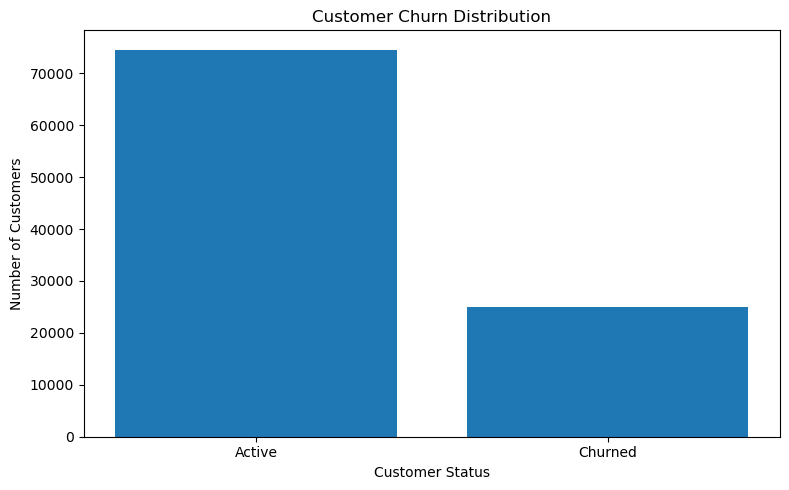

In [34]:
churn_counts = (
    customer_order_activity_df[
        "churned"
    ]
    .value_counts()
    .sort_index()
)

plt.figure(
    figsize=(8, 5)
)

plt.bar(
    [
        "Active",
        "Churned"
    ],
    [
        int(
            churn_counts.get(
                0,
                0
            )
        ),
        int(
            churn_counts.get(
                1,
                0
            )
        )
    ]
)

plt.title(
    "Customer Churn Distribution"
)

plt.xlabel(
    "Customer Status"
)

plt.ylabel(
    "Number of Customers"
)

plt.tight_layout()

plt.show()

In [35]:
model_df = (
    customer_order_activity_df
    .copy()
)

model_df[
    "customer_identifier"
] = (
    model_df[
        order_identifier_column
    ]
    .astype("string")
)

model_feature_columns = [
    "order_count",
    "lifetime_days"
]

X = model_df[
    model_feature_columns
].copy()

y = model_df[
    "churned"
].copy()

for column in model_feature_columns:

    X[column] = pd.to_numeric(
        X[column],
        errors="coerce"
    )

    X[column] = (
        X[column]
        .replace(
            [
                np.inf,
                -np.inf
            ],
            np.nan
        )
    )

if X.empty:

    raise RuntimeError(
        "The model feature matrix is empty."
    )

display(
    X.describe()
)

,order_count,lifetime_days
count,99441.0,99441.0
mean,1.0,0.0
std,0.0,0.0
min,1.0,0.0
25%,1.0,0.0
50%,1.0,0.0
75%,1.0,0.0
max,1.0,0.0


In [36]:
X_train, X_test, y_train, y_test = (
    train_test_split(
        X,
        y,
        test_size=0.20,
        random_state=42,
        stratify=y
    )
)

print(
    "Training rows:",
    len(
        X_train
    )
)

print(
    "Testing rows:",
    len(
        X_test
    )
)

Training rows: 79552
Testing rows: 19889


In [37]:
logistic_model = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(
                strategy="median"
            )
        ),
        (
            "scaler",
            StandardScaler()
        ),
        (
            "model",
            LogisticRegression(
                max_iter=2000,
                class_weight="balanced",
                random_state=42
            )
        )
    ]
)

logistic_model.fit(
    X_train,
    y_train
)

print(
    "Logistic Regression trained."
)

Logistic Regression trained.


In [38]:
random_forest_model = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(
                strategy="median"
            )
        ),
        (
            "model",
            RandomForestClassifier(
                n_estimators=300,
                min_samples_split=5,
                min_samples_leaf=2,
                class_weight="balanced",
                random_state=42,
                n_jobs=-1
            )
        )
    ]
)

random_forest_model.fit(
    X_train,
    y_train
)

print(
    "Random Forest trained."
)

Random Forest trained.


In [39]:
models = {
    "Logistic Regression": logistic_model,
    "Random Forest": random_forest_model
}

model_results = []

for model_name, model in models.items():

    predictions = model.predict(
        X_test
    )

    probabilities = model.predict_proba(
        X_test
    )[
        :,
        1
    ]

    model_results.append(
        {
            "model": model_name,
            "accuracy": accuracy_score(
                y_test,
                predictions
            ),
            "precision": precision_score(
                y_test,
                predictions,
                zero_division=0
            ),
            "recall": recall_score(
                y_test,
                predictions,
                zero_division=0
            ),
            "f1_score": f1_score(
                y_test,
                predictions,
                zero_division=0
            ),
            "roc_auc": roc_auc_score(
                y_test,
                probabilities
            )
        }
    )

model_results_df = (
    pd.DataFrame(
        model_results
    )
    .sort_values(
        "roc_auc",
        ascending=False
    )
    .reset_index(
        drop=True
    )
)

display(
    model_results_df
)

,model,accuracy,precision,recall,f1_score,roc_auc
0,Logistic Regression,0.749661,0.000000,0.0,0.000000,0.5
1,Random Forest,0.250339,0.250339,1.0,0.400434,0.5


In [40]:
best_model_name = (
    model_results_df
    .iloc[
        0
    ][
        "model"
    ]
)

best_model = models[
    best_model_name
]

print(
    "Best model:",
    best_model_name
)

Best model: Logistic Regression


In [41]:
best_predictions = (
    best_model
    .predict(
        X_test
    )
)

best_probabilities = (
    best_model
    .predict_proba(
        X_test
    )[
        :,
        1
    ]
)

print(
    classification_report(
        y_test,
        best_predictions,
        target_names=[
            "Active",
            "Churned"
        ],
        zero_division=0
    )
)

              precision    recall  f1-score   support

      Active       0.75      1.00      0.86     14910
     Churned       0.00      0.00      0.00      4979

    accuracy                           0.75     19889
   macro avg       0.37      0.50      0.43     19889
weighted avg       0.56      0.75      0.64     19889



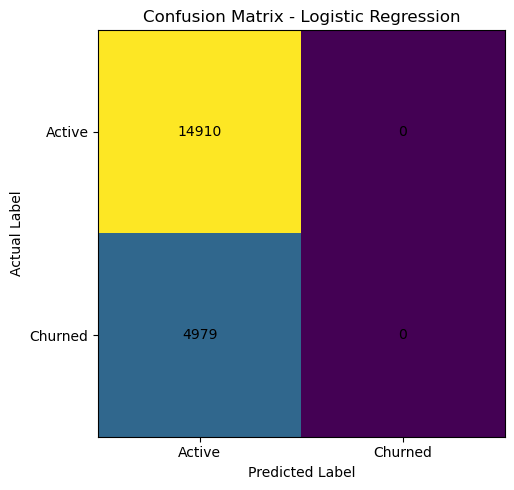

In [42]:
confusion_matrix_values = (
    confusion_matrix(
        y_test,
        best_predictions
    )
)

plt.figure(
    figsize=(7, 5)
)

plt.imshow(
    confusion_matrix_values
)

plt.title(
    f"Confusion Matrix - {best_model_name}"
)

plt.xlabel(
    "Predicted Label"
)

plt.ylabel(
    "Actual Label"
)

plt.xticks(
    [
        0,
        1
    ],
    [
        "Active",
        "Churned"
    ]
)

plt.yticks(
    [
        0,
        1
    ],
    [
        "Active",
        "Churned"
    ]
)

for row_index in range(
    confusion_matrix_values.shape[0]
):

    for column_index in range(
        confusion_matrix_values.shape[1]
    ):

        plt.text(
            column_index,
            row_index,
            confusion_matrix_values[
                row_index,
                column_index
            ],
            ha="center",
            va="center"
        )

plt.tight_layout()

plt.show()

In [43]:
customer_churn_df = (
    model_df[
        [
            "customer_identifier",
            "first_order_date",
            "last_order_date",
            "order_count",
            "lifetime_days",
            "recency_days",
            "churned"
        ]
    ]
    .copy()
)

customer_churn_df[
    "churn_probability"
] = (
    best_model
    .predict_proba(
        X
    )[
        :,
        1
    ]
)

customer_churn_df[
    "churn_prediction"
] = (
    best_model
    .predict(
        X
    )
)

customer_churn_df[
    "risk_level"
] = pd.cut(
    customer_churn_df[
        "churn_probability"
    ],
    bins=[
        -np.inf,
        0.30,
        0.60,
        np.inf
    ],
    labels=[
        "Low Risk",
        "Medium Risk",
        "High Risk"
    ]
)

display(
    customer_churn_df.head()
)

,customer_identifier,first_order_date,last_order_date,order_count,lifetime_days,recency_days,churned,churn_probability,churn_prediction,risk_level
0,00012a2ce6f8dcda20d059ce98491703,2017-11-14 16:08:26,2017-11-14 16:08:26,1,0,337,0,0.5,0,Medium Risk
1,000161a058600d5901f007fab4c27140,2017-07-16 09:40:32,2017-07-16 09:40:32,1,0,458,1,0.5,0,Medium Risk
2,0001fd6190edaaf884bcaf3d49edf079,2017-02-28 11:06:43,2017-02-28 11:06:43,1,0,596,1,0.5,0,Medium Risk
3,0002414f95344307404f0ace7a26f1d5,2017-08-16 13:09:20,2017-08-16 13:09:20,1,0,427,1,0.5,0,Medium Risk
4,000379cdec625522490c315e70c7a9fb,2018-04-02 13:42:17,2018-04-02 13:42:17,1,0,198,0,0.5,0,Medium Risk


In [44]:
if customer_churn_df.empty:

    raise RuntimeError(
        "Customer churn output is empty."
    )

if customer_churn_df[
    "recency_days"
].isna().any():

    raise RuntimeError(
        "Customer churn output contains NaN recency."
    )

if customer_churn_df[
    "churn_probability"
].isna().any():

    raise RuntimeError(
        "Customer churn output contains NaN probabilities."
    )

if (
    customer_churn_df[
        "churn_probability"
    ]
    .lt(0)
    .any()
    or
    customer_churn_df[
        "churn_probability"
    ]
    .gt(1)
    .any()
):

    raise RuntimeError(
        "Invalid churn probabilities detected."
    )

print(
    "Final churn validation passed."
)

Final churn validation passed.


In [45]:
customer_churn_csv_path = (
    OUTPUT_PATH
    / "customer_churn_predictions.csv"
)

model_results_csv_path = (
    OUTPUT_PATH
    / "churn_model_comparison.csv"
)

customer_churn_df.to_csv(
    customer_churn_csv_path,
    index=False
)

model_results_df.to_csv(
    model_results_csv_path,
    index=False
)

print(
    "CSV outputs saved."
)

print(
    customer_churn_csv_path
)

print(
    model_results_csv_path
)

CSV outputs saved.
C:\Users\asus\Documents\ECOMMERCE-AI-PLATFORM\data\processed\customer_churn\customer_churn_predictions.csv
C:\Users\asus\Documents\ECOMMERCE-AI-PLATFORM\data\processed\customer_churn\churn_model_comparison.csv


In [46]:
model_path = (
    OUTPUT_PATH
    / "customer_churn_model.joblib"
)

joblib.dump(
    {
        "model": best_model,
        "features": model_feature_columns,
        "churn_threshold": recency_threshold,
        "observation_date": observation_date,
        "customer_identifier": (
            order_identifier_column
        ),
        "source_schema": order_schema,
        "source_table": order_table
    },
    model_path
)

print(
    "Model saved:"
)

print(
    model_path
)

Model saved:
C:\Users\asus\Documents\ECOMMERCE-AI-PLATFORM\data\processed\customer_churn\customer_churn_model.joblib


In [47]:
customer_churn_table = (
    "customer_churn_predictions"
)

model_results_table = (
    "churn_model_comparison"
)

customer_churn_df.to_sql(
    customer_churn_table,
    engine,
    if_exists="replace",
    index=False,
    method="multi",
    chunksize=5000
)

model_results_df.to_sql(
    model_results_table,
    engine,
    if_exists="replace",
    index=False,
    method="multi",
    chunksize=5000
)

print(
    "Churn results written to PostgreSQL."
)

Churn results written to PostgreSQL.


In [48]:
print(
    "NOTEBOOK 11 COMPLETED SUCCESSFULLY"
)

print()

print(
    "Best model:",
    best_model_name
)

print(
    "Customers analyzed:",
    len(
        customer_churn_df
    )
)

print(
    "Churn threshold:",
    recency_threshold
)

print(
    "PostgreSQL table:",
    customer_churn_table
)

print(
    "CSV output folder:",
    OUTPUT_PATH
)

NOTEBOOK 11 COMPLETED SUCCESSFULLY

Best model: Logistic Regression
Customers analyzed: 99441
Churn threshold: 400.0
PostgreSQL table: customer_churn_predictions
CSV output folder: C:\Users\asus\Documents\ECOMMERCE-AI-PLATFORM\data\processed\customer_churn
